# Grover’s Algorithm

**Grover’s algorithm** provides a quadratic speed‑up for unstructured search problems. It repeatedly applies an **oracle** to mark target states and a **diffusion operator** (amplitude amplification) to increase the probability of measuring a ‘good’ state. In modern Qiskit, we use the `AmplificationProblem` class and `Primitives` (like `Sampler`) to construct and run the algorithm.


## Example: Searching for Marked States

This example searches a four‑qubit space to find marked states (e.g., `'1011'` and `'1010'`). We build a **Phase Oracle** using a logical expression and use the `Grover` class to amplify these states. 

**Installation Note:** Ensure you have the modern stack installed via `pip install qiskit qiskit-algorithms qiskit-aer matplotlib pylatexenc` before running this notebook.


/tmp/ipykernel_887806/1445548221.py:11: DeprecationWarning: The class ``qiskit.circuit.library.phase_oracle.PhaseOracle`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.PhaseOracleGate instead.
  oracle = PhaseOracle(expression)


------------------------------
Top Measurement (Little-Endian): 1101
------------------------------


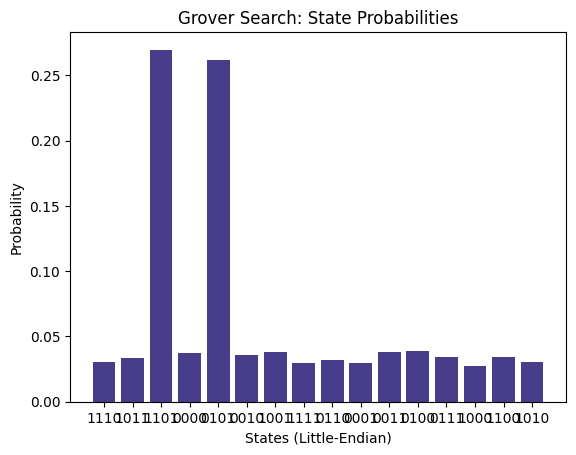

In [4]:
# Grover's Algorithm using Modern Qiskit
from qiskit_algorithms import Grover, AmplificationProblem
from qiskit.circuit.library import PhaseOracle
from qiskit.primitives import StatevectorSampler
import matplotlib.pyplot as plt

# 1. Define the Oracle using a logical expression
# This marks '1011' and '1010' as the target states.
# Note: x3 is the MSB (leftmost bit) in the logic expression.
expression = '(x3 & ~x2 & x1 & x0) | (x3 & ~x2 & x1 & ~x0)'
oracle = PhaseOracle(expression)

# 2. Define the Amplification Problem
problem = AmplificationProblem(oracle)

# 3. Setup Grover with the StatevectorSampler
# We set iterations=1 explicitly to ensure stable circuit construction.
sampler = StatevectorSampler()
grover = Grover(sampler=sampler, iterations=5)

# 4. Run the algorithm
result = grover.amplify(problem)
print("-" * 30)
print(f"Top Measurement (Little-Endian): {result.top_measurement}")
print("-" * 30)

# 5. Visualization
circuit = grover.construct_circuit(problem)
circuit.measure_all()
job = sampler.run([circuit])
counts = job.result()[0].data.meas.get_counts()
total = sum(counts.values())

plt.bar(counts.keys(), [v/total for v in counts.values()], color='darkslateblue')
plt.title("Grover Search: State Probabilities")
plt.xlabel("States (Little-Endian)")
plt.ylabel("Probability")
plt.show()

In [2]:
# Generate LaTeX for Reports
from qiskit.visualization import circuit_drawer
try:
    latex_source = circuit_drawer(circuit, output='latex_source')
    print("--- Copy the LaTeX code below for your report ---")
    print(latex_source)
except Exception as e:
    print("To generate LaTeX, please run: pip install pylatexenc")

To generate LaTeX, please run: pip install pylatexenc


### Exercises

1. **Logical Design:** Modify the `expression` variable to mark a single different state, such as `'0001'`. How does the measurement change?
2. **Iteration Analysis:** Experiment with changing `iterations=1` to `iterations=2`. Does the success probability increase or decrease?
3. **Bit-Ordering:** Qiskit uses Little-Endian ordering. Explain why the target `'1010'` is measured as `'0101'` in the probability plot.